# Implied Volatility

In [1]:
cd -q ../

In [2]:
from src.IV.implied_vol import implied_vol
import matplotlib.pyplot as plt
import yfinance as yf
from datetime import date

In [3]:
ticker = yf.Ticker("SPY")
chain = ticker.option_chain("2026-03-20") 
calls = chain.calls[["strike", "bid", "ask", "lastPrice", "volume", "openInterest"]].copy()
calls["mid"] = (calls["bid"] + calls["ask"]) / 2
calls = calls[calls["strike"] >= 650]
calls = calls[(calls["volume"] > 50) & (calls["openInterest"] > 500)] # Filtered out low-liquidity strikes

In [4]:
S0 = yf.Ticker("SPY").history(period="1d")["Close"].iloc[-1]
T = (date(2026, 3, 20) - date.today()).days / 365
r = 0.05

S0, T, r

(662.2899780273438, 0.010958904109589041, 0.05)

In [5]:
ivs = []
for K, price in zip(calls["strike"], calls["mid"]):
    try:
        iv = implied_vol(price, S0, K, r, T)
        ivs.append((K, iv))
    except ValueError:
        pass

ks, vs = zip(*ivs)

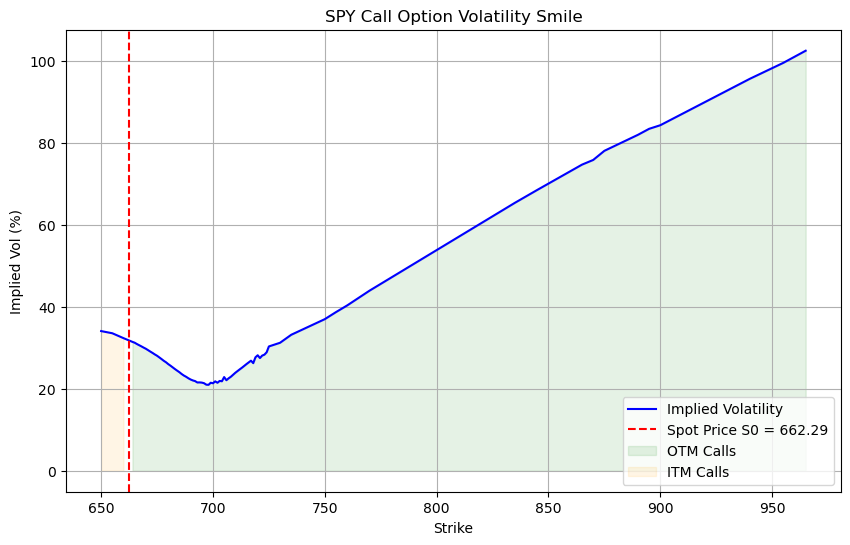

In [6]:
plt.figure(figsize=(10,6))
plt.plot(ks, [v*100 for v in vs], label="Implied Volatility", color="blue")

# Highlight ATM
plt.axvline(S0, color="red", linestyle="--", label=f"Spot Price S0 = {S0:.2f}")

# Highlight OTM and ITM regions for calls
plt.fill_between(ks, [v*100 for v in vs], 0, where=[k>S0 for k in ks], color="green", alpha=0.1, label="OTM Calls")
plt.fill_between(ks, [v*100 for v in vs], 0, where=[k<S0 for k in ks], color="orange", alpha=0.1, label="ITM Calls")

plt.xlabel("Strike")
plt.ylabel("Implied Vol (%)")
plt.title("SPY Call Option Volatility Smile")
plt.grid(True)
plt.legend()
plt.show()